In [1]:
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import accuracy_score, classification_report,recall_score, confusion_matrix,f1_score

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("/home/user/DSP/cleand_wine.csv",index_col=0)

In [3]:
data['quality_group'] = np.where(data['QUALITY'] >= 5, 1, 0)

X = data.drop(['quality_group','rangeofquality','type','QUALITY','residual_sugar', 'free_sulfur_dioxide'], axis=1)
y = data['quality_group']

In [4]:
print(data['quality_group'].value_counts())

quality_group
1    6245
0     246
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

 Logistic Regression

In [7]:
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression
Accuracy: 0.7005388760585065
Recall: 0.7048
F1 Score: 0.8191538819153882
Confusion Matrix:
 [[ 29  20]
 [369 881]]


KNN

In [8]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

SVM

In [9]:
svm = SVC(C=10, gamma='scale',kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

Decision Tree

In [10]:
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators=300, max_depth=20 ,class_weight='balanced',random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.07      0.59      0.13        49
           1       0.98      0.70      0.82      1250

    accuracy                           0.70      1299
   macro avg       0.53      0.65      0.47      1299
weighted avg       0.94      0.70      0.79      1299



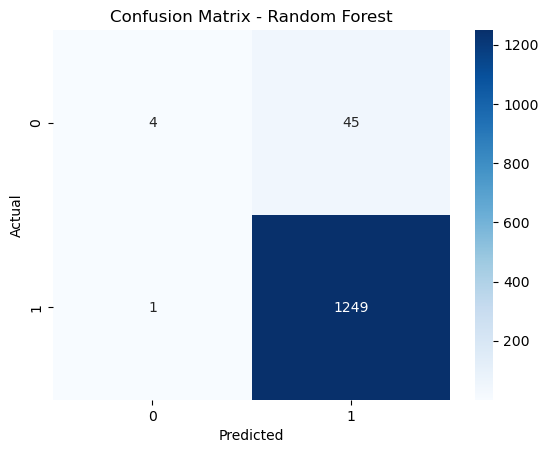

In [13]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()